In [11]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import yaml
from src.path import CONFIG_DIR

#Load config from YAML
with open(CONFIG_DIR / "data.yaml", "r") as f:
    data_config = yaml.safe_load(f)

with open(CONFIG_DIR / "base.yaml", "r") as f:
    base_config = yaml.safe_load(f)

#Set random seed for reproducibility
random_seed = base_config["seed"]

import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import numpy as np

In [12]:
from src.path import RAW_DATA_DIR

#Tạo dataframe sales filter salesamount > 0
sales = pd.read_excel(f'{RAW_DATA_DIR}/VietnamData.xlsx', sheet_name='SCTBH').query('SalesAmount > 0')
sales.head()

,Ngày,Stt,SalesNumber,Mã hàng,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount,Mã KH,Bravo
0,2022-01-03,1339552,HT030122-001,48341-47010,2,240000.0,480000,215000.00,430000.0,DUCMANH-TM,HT
1,2022-01-03,1339552,HT030122-001,T24ZE121B,2,130000.0,260000,77679.14,155358.0,DUCMANH-TM,HT
2,2022-01-03,1339552,HT030122-001,T24ZE121S,2,90000.0,180000,47383.67,94767.0,DUCMANH-TM,HT
3,2022-01-03,1339553,HT030122-002,DTX-162A,1,714286.0,700000,548265.89,548266.0,CONGNGHED6VD-TM,HT
4,2022-01-03,1339553,HT030122-002,CTX-065A,1,816326.0,799999,615591.67,615592.0,CONGNGHED6VD-TM,HT


In [13]:
from src.features.build_features import create_sales_by_item_with_classification

# Classify demand
demand_classify = create_sales_by_item_with_classification(
    sales, product_colID='Mã hàng', totalsales_col='SalesAmount', demand_col='Quantity', adi_method='gap', date_col='Ngày')

demand_classify.head()

,Mã hàng,SalesAmount,ADI,CV2,demand_type
0,.HT-HD-HT,17600049249,0.120158,0.000000,smooth
1,9047,10081716242,12.174757,1.861181,lumpy
2,JK272000-6900,9652811554,0.501796,28.904923,erratic
3,.HT-HD-BW,8229817221,0.227705,0.000000,smooth
4,90919-T1002,6315256743,0.355742,8.577523,erratic


In [14]:
#Classify ABC by Kmeans
from src.features.build_features import classify_abc_by_kmeans

# Apply K-means ABC classification
ABC_demand_classify = classify_abc_by_kmeans(
    demand_classify,
    sales_col='SalesAmount',
    n_clusters=3,
    random_state=random_seed
)

In [20]:
#Classify prodyct lifecycle
#Phân loại vòng đời sản phẩm
from src.features.build_features import classify_product_lifecycle, get_current_lifecycle_stage

# Apply lifecycle classification directly on daily sales data
annual_sales = classify_product_lifecycle(
    sales,
    item_col='Mã hàng',
    date_col='Ngày',
    sales_col='SalesAmount'
)


# Get current lifecycle stage as of 2015
current_stage_by_item = get_current_lifecycle_stage(
    annual_sales,
    year_col='year',
    item_col='Mã hàng',
    as_of_year=2024
)

current_stage_by_item.head(5)

,Mã hàng,year,annual_sales,pct_change,last_annual_sales,first_sales_year,life_cycle_stage
0,1436,2022,1035000,NaN,NaN,2022,Introduction
1,1512,2024,829821,-95.517573,18512760.0,2022,Decline
2,1515,2024,203092736,32.893076,152824167.0,2020,Sustained maturity
3,1519,2023,5872500,NaN,NaN,2023,Introduction
4,1537,2024,436275,-88.842668,3910209.0,2020,Decline


# Visualization

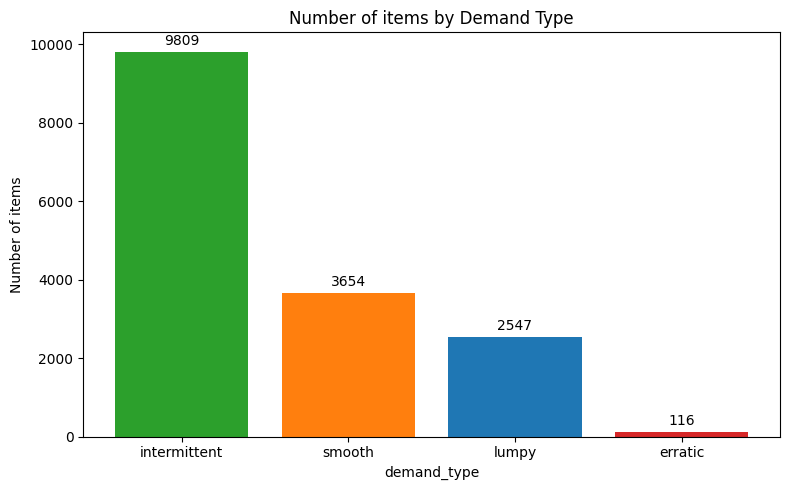

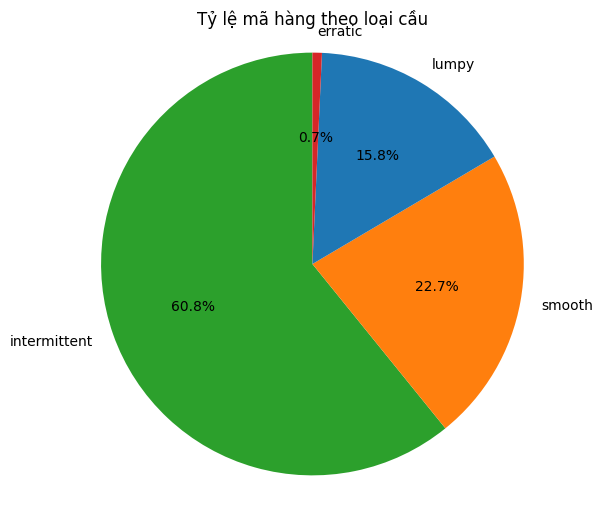

In [15]:
# Đếm số lượng mã hàng theo demand_type (gộp NaN thành 'unknown')
demand_counts = demand_classify['demand_type'].fillna('unknown').value_counts()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(demand_counts.index, demand_counts.values, color=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax.set_title('Number of items by Demand Type')
ax.set_ylabel('Number of items')
ax.set_xlabel('demand_type')

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(demand_counts.values) * 0.01, f'{int(h)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Pie chart (tỷ lệ)
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(demand_counts.values, labels=demand_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax2.set_title('Tỷ lệ mã hàng theo loại cầu')
ax2.axis('equal')
plt.show()

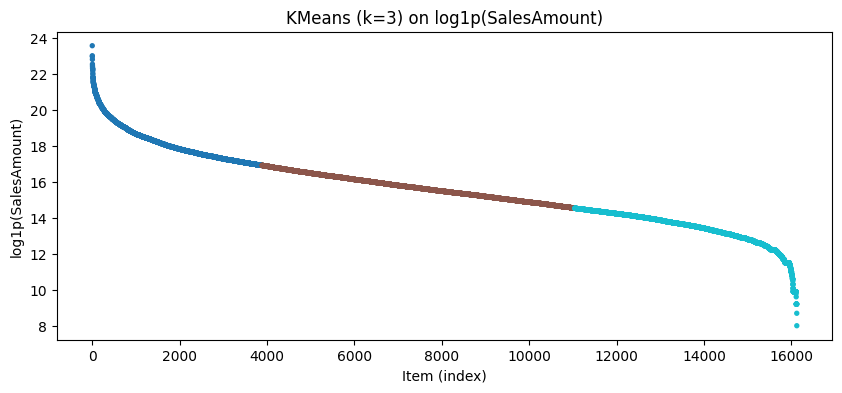

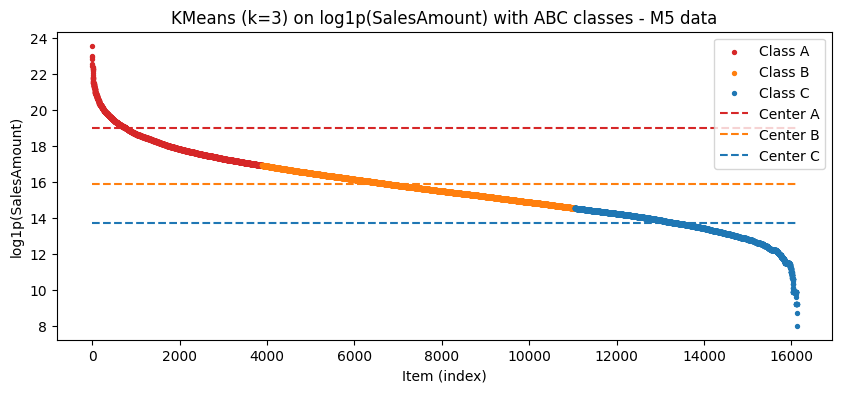

In [17]:
import numpy as np

# Get cluster info for visualization
X_for_clust = np.log1p(ABC_demand_classify['SalesAmount'].values).reshape(-1, 1)
labels3 = ABC_demand_classify['cluster_3'].values
abc_labels = ABC_demand_classify['ABC_class'].values

# ---- Scatter plot log-sales theo cụm số ----
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(np.arange(len(ABC_demand_classify)), X_for_clust.ravel(), c=labels3, cmap='tab10', s=8)
ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(SalesAmount)')
ax.set_title('KMeans (k=3) on log1p(SalesAmount)')

# --- Scatter plot log-sales theo ABC class ---
fig, ax = plt.subplots(figsize=(10, 4))

# Định nghĩa màu cho từng lớp
color_map = {'A': 'tab:red', 'B': 'tab:orange', 'C': 'tab:blue'}

# Vẽ từng lớp A/B/C riêng để có legend rõ ràng
x_idx = np.arange(len(ABC_demand_classify))
for cls in ['A', 'B', 'C']:
    mask = (abc_labels == cls)
    ax.scatter(
        x_idx[mask],
        X_for_clust.ravel()[mask],
        s=8,
        label=f'Class {cls}',
        color=color_map[cls]
    )

ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(SalesAmount)')
ax.set_title('KMeans (k=3) on log1p(SalesAmount) with ABC classes - M5 data')

# Get centers for plotting
centers_log = np.log1p(ABC_demand_classify.groupby('cluster_3')['SalesAmount'].mean().values)
cluster_to_abc = {
    0: 'C' if ABC_demand_classify[ABC_demand_classify['cluster_3'] == 0]['SalesAmount'].mean() < 
        ABC_demand_classify[ABC_demand_classify['cluster_3'] == 1]['SalesAmount'].mean() else
    ('B' if ABC_demand_classify[ABC_demand_classify['cluster_3'] == 0]['SalesAmount'].mean() <
        ABC_demand_classify[ABC_demand_classify['cluster_3'] == 2]['SalesAmount'].mean() else 'A')
}

# Simpler approach: just get from existing ABC mapping
abc_by_cluster = ABC_demand_classify.groupby('cluster_3')['ABC_class'].first().to_dict()
for clust_id, abc in abc_by_cluster.items():
    center_log = np.log1p(ABC_demand_classify[ABC_demand_classify['cluster_3'] == clust_id]['SalesAmount'].mean())
    ax.hlines(
        center_log,
        xmin=0,
        xmax=len(ABC_demand_classify) - 1,
        colors=color_map[abc],
        linestyles='--',
        label=f'Center {abc}'
    )

ax.legend()
plt.show()